In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# !unzip /content/drive/MyDrive/cinic10zip.zip -d /content/data

In [13]:
import os
os.chdir('/kaggle/working')

In [2]:
!git clone http://github.com/michalwietecki/deep-learning-project-1

Cloning into 'deep-learning-project-1'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 168 (delta 66), reused 58 (delta 30), pack-reused 68 (from 2)
Receiving objects: 100% (168/168), 239.65 MiB | 45.54 MiB/s, done.
Resolving deltas: 100% (88/88), done.
Updating files: 100% (18/18), done.


In [3]:
%cd /kaggle/working/deep-learning-project-1

/kaggle/working/deep-learning-project-1


In [3]:
!git config --global user.email "01180649@pw.edu.pl"

In [23]:
!git config --global user.name "michalwietecki"

In [24]:
!git commit -m "Add baseline models"

[main fab6890] Add baseline models
 3 files changed, 0 insertions(+), 0 deletions(-)


In [ ]:
!git push

Username for 'https://github.com': 

In [17]:
!git pull

Already up to date.


In [4]:
import sys
import os

PROJECT_ROOT = "/kaggle/working/deep-learning-project-1"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added:", PROJECT_ROOT)
print("Available modules:", os.listdir(PROJECT_ROOT))

Project root added: /kaggle/working/deep-learning-project-1
Available modules: ['code', 'documents', 'trained_models', '.gitignore', 'README.md', '.git', 'utils', 'main.ipynb', 'experiments_main.ipynb', 'LICENSE']


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import os
import random
import time
import importlib
import utils.config
import utils.models
import utils.data_utils
import utils.evaluation_utils
import numpy as np

from sklearn.metrics import f1_score


importlib.reload(utils.config)
importlib.reload(utils.evaluation_utils)
importlib.reload(utils.models)
importlib.reload(utils.data_utils)

from utils.config import EXPERIMENTS, seed_everything, TRAINED_MODELS_DIR
from utils.models import get_model
from utils.data_utils import get_dataloaders, apply_cutmix


In [6]:
print(EXPERIMENTS)

{'stage_1': {'models': ['baseline_cnn', 'efficientnet_b0', 'efficientnet_b0_pretrained'], 'epochs': 10, 'lr': 0.001, 'batch_size': 128, 'optimizer': 'ADAM', 'augmentations': 'none'}, 'stage_2_test_num_workers_4': {'models': ['baseline_cnn', 'efficientnet_b0'], 'epochs': 1, 'lr': 0.001, 'batch_size': 64, 'optimizer': 'ADAM', 'augmentations': 'none', 'scheduler': 'StepLR'}, 'stage_2_test_num_workers_4_batch_128': {'models': ['baseline_cnn'], 'epochs': 2, 'lr': 0.001, 'batch_size': 128, 'optimizer': 'ADAM', 'augmentations': 'none', 'scheduler': 'StepLR'}, 'stage_2_stepLR': {'models': ['baseline_cnn', 'efficientnet_b0', 'efficientnet_b0_pretrained'], 'epochs': 10, 'lr': 0.001, 'batch_size': 128, 'optimizer': 'ADAM', 'augmentations': 'none', 'scheduler': 'StepLR'}, 'stage_2_MultiStepLR': {'models': ['baseline_cnn', 'efficientnet_b0', 'efficientnet_b0_pretrained'], 'epochs': 10, 'lr': 0.001, 'batch_size': 128, 'optimizer': 'ADAM', 'augmentations': 'none', 'scheduler': 'MultiStepLR'}, 'stage_

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device, config):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, unit="batch", leave=False)
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        if config.get("use_cutmix", False) and random.random() < 0.5:
            inputs, targets_a, targets_b, lam = apply_cutmix(inputs, targets)
            outputs = model(inputs)
            loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.detach().max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        all_preds.extend(predicted.cpu().tolist())
        all_targets.extend(targets.cpu().tolist())
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100.*correct/total:.2f}%")
        del inputs, targets, outputs, loss, predicted

    epoch_f1 = f1_score(all_targets, all_preds, average='weighted')
    return running_loss / len(loader), 100. * correct / total, epoch_f1


def validate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            del inputs, labels, outputs, loss, preds

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_acc, epoch_f1

In [7]:
def run_experiment(stage_name, set_seed=42, num_workers = 4):
    config = EXPERIMENTS[stage_name]
    print(f"\n{'='*30}\n Starting: {stage_name.upper()}\n{'='*30}")

    seed_everything(set_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"device: {device}")

    # create directory for saving models of this stage
    # create directory for saving models of this stage
    GDRIVE_PATH = '/content/drive/MyDrive/dl_1_trained_models'
    
    if os.path.exists('/content/drive/MyDrive'):
        final_base_dir = GDRIVE_PATH
        print(f"Detected Google Drive. Saving to: {final_base_dir}")
    else:
        final_base_dir = TRAINED_MODELS_DIR
        print(f"Google Drive not detected. Saving locally to: {final_base_dir}")

    stage_save_dir = os.path.join(final_base_dir, stage_name)
    os.makedirs(stage_save_dir, exist_ok=True)

    # stage_save_dir = os.path.join(TRAINED_MODELS_DIR, stage_name)
    # os.makedirs(stage_save_dir, exist_ok=True)

    # prepare both train and validation dataloaders
    train_loader = get_dataloaders(config, split='train', num_workers = num_workers)
    val_loader = get_dataloaders(config, split='test', num_workers = num_workers)

    # loop of all models in this stage
    for model_name in config["models"]:
        print(f"\n==-------- Model: {model_name} --------==")

        import gc
        gc.collect()
        torch.cuda.empty_cache()

        model = get_model(model_name, config).to(device)
        # for double gpu
        # if torch.cuda.device_count() > 1:
        #     print(f"Found {torch.cuda.device_count()} GPU. Usingnn.DataParallel.")
        #     model = nn.DataParallel(model)
            
        criterion = nn.CrossEntropyLoss()

        optimizer = optim.Adam(
            model.parameters(),
            lr=config.get("lr", 0.001),
            weight_decay=config.get("weight_decay", 0)
        )

        # set scheduler
        scheduler_type = config.get("scheduler", None)
        scheduler = None

        if scheduler_type == "StepLR":
            # decrease LR by a factor of 0.1 every 5 epochs
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.3)

        elif scheduler_type == "MultiStepLR":
            # decrease LR in specific epochs (e.g., 10 and 15)
            scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[6, 9], gamma=0.1)
        elif scheduler_type == "CosineAnnealingLR":
            # LR follows a cosine curve, T_max is the number of epochs for one cycle
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
        elif scheduler_type == "ReduceLROnPlateau":
            # decrease LR when a validation loss has stopped improving
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)
        history = {
            'epoch': [],
            'train_loss': [], 'train_acc': [], 'train_f1': [],
            'val_loss': [], 'val_acc': [], 'val_f1': [],
            'lr': [], 'epoch_time': []
        }

        # main training loop
        epochs = config.get("epochs", 10)
        for epoch in range(epochs):
            print(f"Epoch {epoch+1}/{epochs}")
            start_time = time.time()

            train_loss, train_acc, train_f1 = train_one_epoch(
                model, train_loader, criterion, optimizer, device, config
            )

            epoch_time = time.time() - start_time

            v_loss, v_acc, v_f1 = validate_model(model, val_loader, criterion, device)
            
            current_lr = optimizer.param_groups[0]['lr']

            if scheduler:
                if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(v_loss) # reacts to validation loss
                else:
                    scheduler.step()

            history['epoch'].append(epoch + 1)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['train_f1'].append(train_f1)
            history['val_loss'].append(v_loss)
            history['val_acc'].append(v_acc)
            history['val_f1'].append(v_f1)
            history['lr'].append(current_lr)
            history['epoch_time'].append(epoch_time)

            gc.collect()
            torch.cuda.empty_cache()

            print(f"Epoch results: Loss: {train_loss:.4f} | Acc: {train_acc:.2f}% | F1: {train_f1:.4f} | "
                  f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}% | Val F1: {v_f1:.4f} | "
                  f"LR: {current_lr:.6f} | Czas: {epoch_time:.2f}s")
            
        # save model and its history (handle nn.parallel)
        save_path = os.path.join(stage_save_dir, f"{model_name}.pth")
        
        state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        
        torch.save({
            'model_state_dict': state_dict,
            'config': config,
            'history': history
        }, save_path)
        print(f"Model saved: {save_path}")

In [ ]:
run_experiment("stage_1")


URUCHAMIAM: STAGE_1
Full reproducibility with seed set at: 42
Urządzenie: cuda

--- Model: baseline_cnn ---
Epoka 1/10


Wynik epoki: Loss: 1.5408 | Acc: 43.79%
Epoka 2/10


Wynik epoki: Loss: 1.2092 | Acc: 56.25%
Epoka 3/10


Wynik epoki: Loss: 0.9582 | Acc: 65.69%
Epoka 4/10


Wynik epoki: Loss: 0.6377 | Acc: 77.26%
Epoka 5/10


...

100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


Epoka 1/10


Wynik epoki: Loss: 0.6208 | Acc: 78.29%
Epoka 2/10


Wynik epoki: Loss: 0.4335 | Acc: 84.81%
Epoka 3/10


 25%|██▌       | 356/1407 [01:53<05:35,  3.13batch/s, acc=87.79%, loss=0.4111]

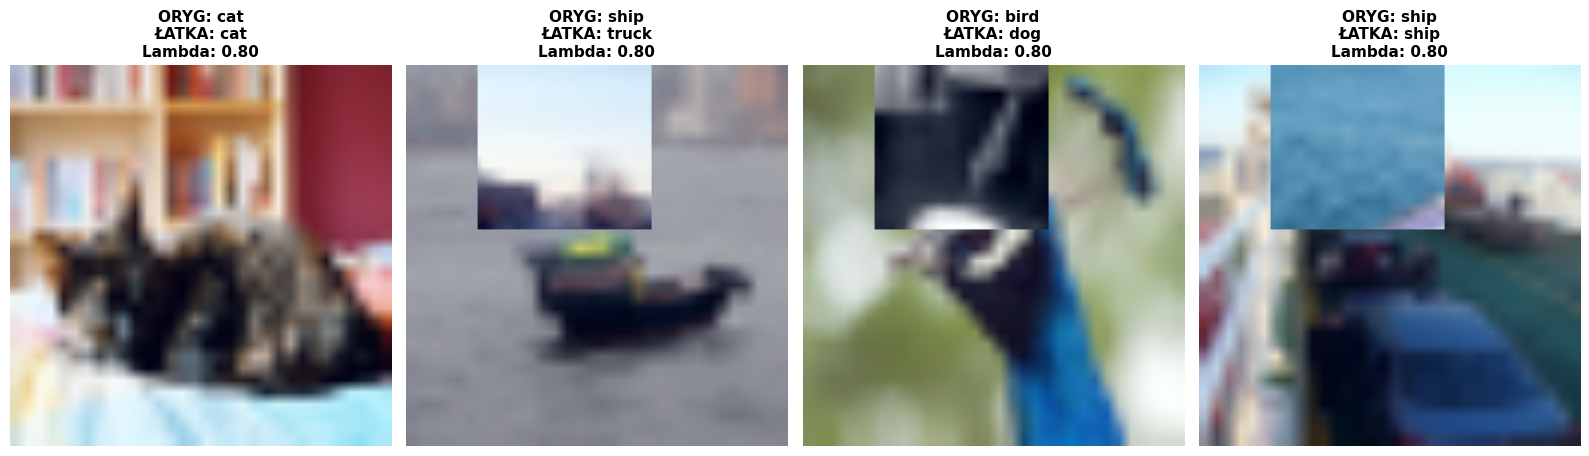

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

config_test = EXPERIMENTS["stage_1"]
temp_loader = get_dataloaders(config_test, split='train')

inputs, targets = next(iter(temp_loader))

mixed_inputs, targets_a, targets_b, lam = apply_cutmix(inputs.clone(), targets.clone())

plt.figure(figsize=(16, 8))

for i in range(4):
    plt.subplot(1, 4, i+1)

    img = mixed_inputs[i].permute(1, 2, 0).cpu().numpy()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    title = f"ORYG: {classes[targets_a[i]]}\n"
    title += f"ŁATKA: {classes[targets_b[i]]}\n"
    title += f"Lambda: {lam:.2f}"

    plt.title(title, fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
run_experiment("stage_4_test_1")


 Starting: STAGE_4_TEST_1
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Epoch 1/3


Epoch results: Loss: 1.7934 | Acc: 35.90% | Val Loss: 1.4179 | Val Acc: 48.70% | LR: 0.001000 | Czas: 213.66s
Epoch 2/3


Epoch results: Loss: 1.5375 | Acc: 46.09% | Val Loss: 1.2590 | Val Acc: 54.25% | LR: 0.000750 | Czas: 220.49s
Epoch 3/3


Epoch results: Loss: 1.3458 | Acc: 54.36% | Val Loss: 1.1906 | Val Acc: 57.10% | LR: 0.000250 | Czas: 211.09s
Model saved: ./trained_models/stage_4_test_1/baseline_cnn.pth

==-------- Model: efficientnet_b0_pretrained --------==
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s]


Epoch 1/3


Epoch results: Loss: 1.0526 | Acc: 65.94% | Val Loss: 0.5733 | Val Acc: 81.01% | LR: 0.001000 | Czas: 445.72s
Epoch 2/3


Epoch results: Loss: 0.8437 | Acc: 73.17% | Val Loss: 0.4254 | Val Acc: 86.04% | LR: 0.000750 | Czas: 448.24s
Epoch 3/3


Epoch results: Loss: 0.6936 | Acc: 77.57% | Val Loss: 0.3162 | Val Acc: 89.21% | LR: 0.000250 | Czas: 447.63s
Model saved: ./trained_models/stage_4_test_1/efficientnet_b0_pretrained.pth


In [ ]:
import torch
import pandas as pd
import os
path_to_model = './trained_models/stage_4_test_1/baseline_cnn.pth'


checkpoint = torch.load(path_to_model, map_location='cpu')
history = checkpoint.get('history', {})
df = pd.DataFrame(history)
display(df.head(20))


,epoch,train_loss,train_acc,val_loss,val_acc,lr,epoch_time
0,1,1.793374,35.901111,1.417910,48.703333,0.00100,213.655836
1,2,1.537496,46.093333,1.258963,54.253333,0.00075,220.494564
2,3,1.345796,54.363333,1.190581,57.097778,0.00025,211.091166


In [12]:
run_experiment("stage_2_test_num_workers_4")


 Starting: STAGE_2_TEST_NUM_WORKERS_4
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/1


Epoch results: Loss: 1.5425 | Acc: 43.66% | Val Loss: 1.3681 | Val Acc: 50.27% | LR: 0.001000 | Czas: 276.70s
Model saved: ./trained_models/stage_2_test_num_workers_4/baseline_cnn.pth

==-------- Model: efficientnet_b0 --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/1


Epoch results: Loss: 1.5407 | Acc: 42.48% | Val Loss: 1.2272 | Val Acc: 54.69% | LR: 0.001000 | Czas: 310.68s
Model saved: ./trained_models/stage_2_test_num_workers_4/efficientnet_b0.pth


In [12]:
run_experiment("stage_2_test_num_workers_4_batch_128")


 Starting: STAGE_2_TEST_NUM_WORKERS_4_BATCH_128
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/2


Epoch results: Loss: 1.5625 | Acc: 43.23% | Val Loss: 1.3869 | Val Acc: 49.87% | LR: 0.001000 | Czas: 158.80s
Epoch 2/2


Epoch results: Loss: 1.2266 | Acc: 55.60% | Val Loss: 1.2716 | Val Acc: 54.25% | LR: 0.001000 | Czas: 110.68s
Model saved: ./trained_models/stage_2_test_num_workers_4_batch_128/baseline_cnn.pth


code	   experiments_main.ipynb  main.ipynb  trained_models
documents  LICENSE		   README.md   utils


In [2]:
import torch
import pandas as pd
import os
path_to_model = './trained_models/stage_2_test_num_workers_4_batch_128/baseline_cnn.pth'


checkpoint = torch.load(path_to_model, map_location='cpu')
history = checkpoint.get('history', {})
df = pd.DataFrame(history)
display(df.head(20))


FileNotFoundError: [Errno 2] No such file or directory: './trained_models/stage_2_test_num_workers_4_batch_128/baseline_cnn.pth'

## Correct ones

In [12]:
run_experiment("stage_1")


 Starting: STAGE_1
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/10


Epoch results: Loss: 3.3399 | Acc: 28.62% | Val Loss: 1.7787 | Val Acc: 35.61% | LR: 0.001000 | Czas: 610.79s
Epoch 2/10


Epoch results: Loss: 1.6274 | Acc: 39.63% | Val Loss: 1.5655 | Val Acc: 42.08% | LR: 0.001000 | Czas: 618.77s
Epoch 3/10


Epoch results: Loss: 1.4640 | Acc: 45.57% | Val Loss: 1.4326 | Val Acc: 47.27% | LR: 0.001000 | Czas: 621.72s
Epoch 4/10


Epoch results: Loss: 1.3747 | Acc: 48.82% | Val Loss: 1.4133 | Val Acc: 48.04% | LR: 0.001000 | Czas: 621.17s
Epoch 5/10


...

Epoch results: Loss: 0.1786 | Acc: 93.61% | Val Loss: 0.4268 | Val Acc: 87.45% | LR: 0.001000 | Czas: 252.42s
Epoch 7/10


Epoch results: Loss: 0.1576 | Acc: 94.41% | Val Loss: 0.4267 | Val Acc: 87.53% | LR: 0.001000 | Czas: 253.18s
Epoch 8/10


Epoch results: Loss: 0.1381 | Acc: 95.16% | Val Loss: 0.4240 | Val Acc: 87.61% | LR: 0.001000 | Czas: 253.08s
Epoch 9/10


Epoch results: Loss: 0.1216 | Acc: 95.84% | Val Loss: 0.4573 | Val Acc: 87.21% | LR: 0.001000 | Czas: 254.34s
Epoch 10/10


Epoch results: Loss: 0.1134 | Acc: 96.04% | Val Loss: 0.4981 | Val Acc: 87.06% | LR: 0.001000 | Czas: 255.51s
Model saved: ./trained_models/stage_1/efficientnet_b0_pretrained.pth


In [10]:
run_experiment("stage_2_stepLR")


 Starting: STAGE_2_STEPLR
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/10


Epoch results: Loss: 3.3399 | Acc: 28.62% | Val Loss: 1.7787 | Val Acc: 35.61% | LR: 0.001000 | Czas: 635.80s
Epoch 2/10


Epoch results: Loss: 1.6274 | Acc: 39.63% | Val Loss: 1.5655 | Val Acc: 42.08% | LR: 0.001000 | Czas: 643.78s
Epoch 3/10


Epoch results: Loss: 1.4640 | Acc: 45.57% | Val Loss: 1.4326 | Val Acc: 47.27% | LR: 0.001000 | Czas: 647.32s
Epoch 4/10


Epoch results: Loss: 1.3042 | Acc: 51.51% | Val Loss: 1.3299 | Val Acc: 50.69% | LR: 0.000300 | Czas: 648.51s
Epoch 5/10


...

Epoch results: Loss: 0.0606 | Acc: 97.90% | Val Loss: 0.4126 | Val Acc: 89.51% | LR: 0.000300 | Czas: 261.71s
Epoch 7/10


Epoch results: Loss: 0.0317 | Acc: 98.97% | Val Loss: 0.4190 | Val Acc: 90.22% | LR: 0.000090 | Czas: 261.79s
Epoch 8/10


Epoch results: Loss: 0.0217 | Acc: 99.32% | Val Loss: 0.4552 | Val Acc: 90.27% | LR: 0.000090 | Czas: 261.43s
Epoch 9/10


Epoch results: Loss: 0.0179 | Acc: 99.45% | Val Loss: 0.4676 | Val Acc: 90.30% | LR: 0.000090 | Czas: 261.14s
Epoch 10/10


Epoch results: Loss: 0.0133 | Acc: 99.59% | Val Loss: 0.4666 | Val Acc: 90.46% | LR: 0.000027 | Czas: 259.42s
Model saved: ./trained_models/stage_2_stepLR/efficientnet_b0_pretrained.pth


In [14]:
!ls

code	   experiments_main.ipynb  main.ipynb  trained_models
documents  LICENSE		   README.md   utils


In [ ]:
import torch
import pandas as pd
import os
path_to_model = './trained_models/stage_2_test_num_workers_4_batch_128/baseline_cnn.pth'


checkpoint = torch.load(path_to_model, map_location='cpu')
history = checkpoint.get('history', {})
df = pd.DataFrame(history)
display(df.head(20))


In [13]:
run_experiment("stage_2_CosineAnnealingLR")


 Starting: STAGE_2_COSINEANNEALINGLR
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/10


Epoch results: Loss: 3.3399 | Acc: 28.62% | Val Loss: 1.7787 | Val Acc: 35.61% | LR: 0.001000 | Czas: 643.73s
Epoch 2/10


Epoch results: Loss: 1.6266 | Acc: 39.74% | Val Loss: 1.5410 | Val Acc: 42.36% | LR: 0.000976 | Czas: 650.50s
Epoch 3/10


Epoch results: Loss: 1.4610 | Acc: 45.78% | Val Loss: 1.4072 | Val Acc: 48.10% | LR: 0.000905 | Czas: 652.01s
Epoch 4/10


Epoch results: Loss: 1.3636 | Acc: 49.28% | Val Loss: 1.3603 | Val Acc: 49.82% | LR: 0.000794 | Czas: 653.00s
Epoch 5/10


...

Epoch results: Loss: 0.0904 | Acc: 96.83% | Val Loss: 0.4016 | Val Acc: 89.04% | LR: 0.000500 | Czas: 259.89s
Epoch 7/10


Epoch results: Loss: 0.0487 | Acc: 98.32% | Val Loss: 0.4483 | Val Acc: 89.54% | LR: 0.000345 | Czas: 259.42s
Epoch 8/10


Epoch results: Loss: 0.0273 | Acc: 99.11% | Val Loss: 0.4689 | Val Acc: 90.01% | LR: 0.000206 | Czas: 259.85s
Epoch 9/10


Epoch results: Loss: 0.0163 | Acc: 99.51% | Val Loss: 0.4761 | Val Acc: 90.30% | LR: 0.000095 | Czas: 259.57s
Epoch 10/10


Epoch results: Loss: 0.0108 | Acc: 99.69% | Val Loss: 0.4693 | Val Acc: 90.48% | LR: 0.000024 | Czas: 260.93s
Model saved: ./trained_models/stage_2_CosineAnnealingLR/efficientnet_b0_pretrained.pth


In [11]:
run_experiment("stage_2_LR_0.0003")


 Starting: STAGE_2_LR_0.0003
Full reproducibility with seed set at: 42
device: cuda

==-------- Model: baseline_cnn --------==
Found 2 GPU. Usingnn.DataParallel.
Epoch 1/10


Epoch results: Loss: 2.1693 | Acc: 35.04% | Val Loss: 1.5774 | Val Acc: 42.59% | LR: 0.000300 | Czas: 674.60s
Epoch 2/10


Epoch results: Loss: 1.4231 | Acc: 48.14% | Val Loss: 1.3528 | Val Acc: 50.49% | LR: 0.000300 | Czas: 687.88s
Epoch 3/10


Epoch results: Loss: 1.2617 | Acc: 54.15% | Val Loss: 1.2744 | Val Acc: 53.61% | LR: 0.000300 | Czas: 689.86s
Epoch 4/10


Epoch results: Loss: 1.1509 | Acc: 58.41% | Val Loss: 1.2003 | Val Acc: 56.25% | LR: 0.000300 | Czas: 691.35s
Epoch 5/10


...

Epoch results: Loss: 0.0969 | Acc: 96.62% | Val Loss: 0.3600 | Val Acc: 89.69% | LR: 0.000300 | Czas: 277.33s
Epoch 7/10


Epoch results: Loss: 0.0810 | Acc: 97.17% | Val Loss: 0.4053 | Val Acc: 89.75% | LR: 0.000300 | Czas: 276.60s
Epoch 8/10


Epoch results: Loss: 0.0745 | Acc: 97.41% | Val Loss: 0.4080 | Val Acc: 89.82% | LR: 0.000300 | Czas: 275.98s
Epoch 9/10


Epoch results: Loss: 0.0662 | Acc: 97.71% | Val Loss: 0.4236 | Val Acc: 89.72% | LR: 0.000300 | Czas: 277.02s
Epoch 10/10


Epoch results: Loss: 0.0606 | Acc: 97.90% | Val Loss: 0.4389 | Val Acc: 89.65% | LR: 0.000300 | Czas: 276.33s
Model saved: ./trained_models/stage_2_LR_0.0003/efficientnet_b0_pretrained.pth


In [39]:
import torch
import pandas as pd
import os
path_to_model = './trained_models/stage_3_dropout/baseline_cnn_2222.pth'


checkpoint = torch.load(path_to_model, map_location='cpu',weights_only=False)
history = checkpoint.get('history', {})
df = pd.DataFrame(history)
display(df.head(20))
config_test = checkpoint.get('config', {})
df_c = pd.DataFrame(config_test)
display(df_c.head(20))


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,lr,epoch_time
0,1,3.382537,22.513333,0.204094,1.932561,29.471111,0.257739,0.001000,604.337509
1,2,1.805197,31.437778,0.302287,1.624629,38.478889,0.352266,0.000976,605.615762
2,3,1.665271,36.850000,0.362268,1.585336,40.568889,0.364023,0.000905,606.367898
3,4,1.579785,40.010000,0.395823,1.464203,46.206667,0.453591,0.000794,607.182791
4,5,1.527456,42.136667,0.419220,1.432557,47.015556,0.453572,0.000655,607.796576
5,6,1.474795,44.046667,0.439036,1.365608,50.301111,0.497854,0.000500,608.064540
6,7,1.421672,45.688889,0.456757,1.310088,52.308889,0.517363,0.000345,609.211610
7,8,1.372381,47.634444,0.476693,1.271825,54.022222,0.540959,0.000206,609.620713
8,9,1.328751,49.234444,0.493516,1.230058,55.291111,0.549833,0.000095,609.658783
9,10,1.293357,50.480000,0.505948,1.217227,56.011111,0.560320,0.000024,610.371244


,models,epochs,lr,batch_size,optimizer,scheduler,weight_decay,dropout
0,baseline_cnn,10,0.001,128,ADAM,CosineAnnealingLR,0.0,0.2
1,efficientnet_b0,10,0.001,128,ADAM,CosineAnnealingLR,0.0,0.2
2,efficientnet_b0_pretrained,10,0.001,128,ADAM,CosineAnnealingLR,0.0,0.2


In [8]:
run_experiment("stage_4_mix_soft_cut", num_workers = 2)


 Starting: STAGE_4_MIX_SOFT_CUT
Full reproducibility with seed set at: 42
device: cuda
Google Drive not detected. Saving locally to: ./trained_models/

==-------- Model: efficientnet_b0 --------==
Epoch 1/10


Epoch results: Loss: 1.7696 | Acc: 35.56% | F1: 0.3487 | Val Loss: 1.3411 | Val Acc: 50.90% | Val F1: 0.5011 | LR: 0.001000 | Czas: 455.88s
Epoch 2/10


Epoch results: Loss: 1.4685 | Acc: 47.96% | F1: 0.4758 | Val Loss: 1.2165 | Val Acc: 58.69% | Val F1: 0.5913 | LR: 0.000976 | Czas: 438.50s
Epoch 3/10


Epoch results: Loss: 1.3087 | Acc: 55.42% | F1: 0.5510 | Val Loss: 1.1114 | Val Acc: 64.21% | Val F1: 0.6404 | LR: 0.000905 | Czas: 438.25s
Epoch 4/10


Epoch results: Loss: 1.2411 | Acc: 57.29% | F1: 0.5704 | Val Loss: 1.2043 | Val Acc: 68.28% | Val F1: 0.6808 | LR: 0.000794 | Czas: 438.73s
Epoch 5/10


KeyboardInterrupt: 